# Cancer images — YOLOv8 + CBAM attention (the contribution / ablation)

**BM3 — Image-based Cancer Cell Detection using Deep Learning** (Rafay Nisar).

Adds **CBAM (channel + spatial attention)** to the YOLOv8 backbone and trains **baseline YOLOv8 vs YOLOv8+CBAM** on the same 23 cancer images / same split — your attention ablation.

CBAM is **defined and registered here** (some Ultralytics versions raise `KeyError: 'CBAM'` otherwise). Runtime -> **T4 GPU**. **Untested by me — paste any error and I'll fix it.**

## 0. Install + define/register CBAM

In [ ]:
!pip -q install ultralytics
import os, glob, json, random, shutil, numpy as np
import torch, torch.nn as nn
from ultralytics import YOLO
from google.colab import drive
drive.mount('/content/drive')

class ChannelAttention(nn.Module):
    def __init__(self, c, r=16):
        super().__init__(); h = max(c // r, 1)
        self.avg = nn.AdaptiveAvgPool2d(1); self.mx = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(nn.Conv2d(c, h, 1, bias=False), nn.ReLU(), nn.Conv2d(h, c, 1, bias=False)); self.sig = nn.Sigmoid()
    def forward(self, x): return x * self.sig(self.mlp(self.avg(x)) + self.mlp(self.mx(x)))
class SpatialAttention(nn.Module):
    def __init__(self, k=7):
        super().__init__(); self.conv = nn.Conv2d(2, 1, k, padding=k//2, bias=False); self.sig = nn.Sigmoid()
    def forward(self, x):
        a = x.mean(1, keepdim=True); mx, _ = x.max(1, keepdim=True)
        return x * self.sig(self.conv(torch.cat([a, mx], 1)))
class CBAM(nn.Module):
    def __init__(self, c1, kernel_size=7):
        super().__init__(); self.ca = ChannelAttention(c1); self.sa = SpatialAttention(kernel_size)
    def forward(self, x): return self.sa(self.ca(x))
import ultralytics.nn.tasks as _tasks
_tasks.CBAM = CBAM
print('CBAM registered | GPU:', torch.cuda.is_available())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 7.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Mounted at /content/drive
CBAM registered | GPU: True


## 1. Convert labelme -> YOLO + split (same seed as the multi-model notebook)

In [ ]:
SRC = '/content/drive/MyDrive/Cancer Dataset/annotated_images'   # >>> EDIT to where you uploaded it
jsons = sorted(glob.glob(os.path.join(SRC, '*.json')))
assert len(jsons) > 0, 'No .json found - fix SRC'
ROOT = '/content/cancer_yolo'
if os.path.exists(ROOT): shutil.rmtree(ROOT)
for s in ['train', 'valid', 'test']:
    os.makedirs(f'{ROOT}/{s}/images', exist_ok=True); os.makedirs(f'{ROOT}/{s}/labels', exist_ok=True)

def find_image(jp, a):
    base = os.path.splitext(jp)[0]
    for ext in ['.png','.jpeg','.jpg','.PNG','.JPEG','.JPG','.tif','.tiff']:
        if os.path.exists(base+ext): return base+ext
    cand = os.path.join(SRC, os.path.basename(a.get('imagePath','')))
    return cand if os.path.exists(cand) else None
def poly_bbox(points, W, H):
    xs=[p[0] for p in points]; ys=[p[1] for p in points]
    x1,y1,x2,y2 = max(0,min(xs)),max(0,min(ys)),min(W,max(xs)),min(H,max(ys))
    return ((x1+x2)/2/W,(y1+y2)/2/H,(x2-x1)/W,(y2-y1)/H) if x2>x1 and y2>y1 else None

pairs = []
for jp in jsons:
    a = json.load(open(jp, encoding='utf-8')); img = find_image(jp, a)
    if img: pairs.append((img, jp, a))
random.seed(42); random.shuffle(pairs)
n=len(pairs); n_test=max(2,int(0.15*n)); n_val=max(2,int(0.15*n))
splits={'test':pairs[:n_test],'valid':pairs[n_test:n_test+n_val],'train':pairs[n_test+n_val:]}
for split, items in splits.items():
    for img, jp, a in items:
        W=a.get('imageWidth'); H=a.get('imageHeight'); stem=os.path.splitext(os.path.basename(img))[0].replace(' ','_')
        shutil.copy(img, f'{ROOT}/{split}/images/{stem}{os.path.splitext(img)[1]}')
        lines=[]
        for s in a.get('shapes', []):
            bb=poly_bbox(s.get('points',[]), W, H)
            if bb: lines.append('0 '+' '.join(f'{v:.6f}' for v in bb))
        open(f'{ROOT}/{split}/labels/{stem}.txt','w').write('\n'.join(lines))
    print(split, len(items))
open(f'{ROOT}/data.yaml','w').write(f"path: {ROOT}\ntrain: train/images\nval: valid/images\ntest: test/images\nnc: 1\nnames: ['cancer-cell']\n")
print('data.yaml written')

test 3
valid 3
train 17
data.yaml written


## 2. Write the CBAM-augmented YOLOv8 (CBAM after SPPF)

In [ ]:
cbam = '''# YOLOv8s + CBAM
nc: 1
scales:
  s: [0.33, 0.50, 1024]
backbone:
  - [-1, 1, Conv, [64, 3, 2]]
  - [-1, 1, Conv, [128, 3, 2]]
  - [-1, 3, C2f, [128, True]]
  - [-1, 1, Conv, [256, 3, 2]]
  - [-1, 6, C2f, [256, True]]
  - [-1, 1, Conv, [512, 3, 2]]
  - [-1, 6, C2f, [512, True]]
  - [-1, 1, Conv, [1024, 3, 2]]
  - [-1, 3, C2f, [1024, True]]
  - [-1, 1, SPPF, [1024, 5]]
  - [-1, 1, CBAM, [512]]
head:
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]
  - [[-1, 6], 1, Concat, [1]]
  - [-1, 3, C2f, [512]]
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]
  - [[-1, 4], 1, Concat, [1]]
  - [-1, 3, C2f, [256]]
  - [-1, 1, Conv, [256, 3, 2]]
  - [[-1, 13], 1, Concat, [1]]
  - [-1, 3, C2f, [512]]
  - [-1, 1, Conv, [512, 3, 2]]
  - [[-1, 10], 1, Concat, [1]]
  - [-1, 3, C2f, [1024]]
  - [[16, 19, 22], 1, Detect, [nc]]
'''
open('/content/yolov8s-cbam.yaml','w').write(cbam)
m = YOLO('/content/yolov8s-cbam.yaml')
print('CBAM model built OK |', sum(p.numel() for p in m.model.parameters()), 'params')

CBAM model built OK | 11168853 params


## 3. Train baseline YOLOv8 and YOLOv8+CBAM (identical settings)

In [ ]:
WORK = '/content/drive/MyDrive/cancer_images'; os.makedirs(WORK, exist_ok=True)
IMG, EPOCHS = 1280, 200
AUG = dict(degrees=10, translate=0.1, scale=0.5, fliplr=0.5, mosaic=1.0)

YOLO('yolov8s.pt').train(data=f'{ROOT}/data.yaml', epochs=EPOCHS, imgsz=IMG, batch=4, patience=50,
                         project=WORK, name='cancer_base', exist_ok=True, **AUG)
YOLO('/content/yolov8s-cbam.yaml').load('yolov8s.pt').train(data=f'{ROOT}/data.yaml', epochs=EPOCHS, imgsz=IMG,
                         batch=4, patience=50, project=WORK, name='cancer_cbam', exist_ok=True, **AUG)
print('both trained')

Ultralytics 8.4.137 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/cancer_yolo/data.yaml, degrees=10, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cancer_base, nbs=64, nms=False, o

/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      1/200       3.7G      4.686        8.7      4.273          4       1280: 100% ━━━━━━━━━━━━ 5/5 2.7it/s 1.9s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.3it/s 0.4s
                   all          3          5          0          0          0          0

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/200       3.7G      5.073      11.18      4.225         12       1280: 0% ──────────── 0/5  0.3s

/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      2/200       3.7G      4.813       14.3      4.208          1       1280: 100% ━━━━━━━━━━━━ 5/5 3.7it/s 1.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.8it/s 0.6s
                   all          3          5          0          0          0          0

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/200       3.7G      4.755      5.608      4.153         32       1280: 0% ──────────── 0/5  0.2s

...

    136/200      3.73G      2.216      2.616      2.215          4       1280: 100% ━━━━━━━━━━━━ 5/5 5.1it/s 1.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.2it/s 0.3s
                   all          3          5          1      0.369      0.519      0.107

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    137/200      3.73G      1.895      2.515      2.076         14       1280: 0% ──────────── 0/5  0.2s

/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


    137/200      3.73G      1.786      2.542      2.076          5       1280: 100% ━━━━━━━━━━━━ 5/5 4.8it/s 1.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.3it/s 0.3s
                   all          3          5          1      0.369      0.519      0.107

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    138/200      3.73G      1.842       2.15      2.143         14       1280: 0% ──────────── 0/5  0.2s

/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


    138/200      3.73G      1.738      1.977      1.998          4       1280: 100% ━━━━━━━━━━━━ 5/5 5.1it/s 1.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.9it/s 0.3s
                   all          3          5          1      0.369      0.519      0.107
EarlyStopping: Training stopped early as no improvement observed in last 50 epochs. Best results observed at epoch 88, best model saved as best.pt.
To update EarlyStopping(patience=50) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

138 epochs completed in 0.092 hours.
Optimizer stripped from /content/drive/MyDrive/cancer_images/cancer_cbam/weights/last.pt, 22.7MB
Optimizer stripped from /content/drive/MyDrive/cancer_images/cancer_cbam/weights/best.pt, 22.7MB

Validating /content/drive/MyDrive/cancer_images/cancer_cbam/weights/best.pt...
Ultralytics 8.4.137 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB

## 4. Evaluate both (mAP + count MAE) and compare

In [ ]:
test_imgs = sorted(glob.glob(f'{ROOT}/test/images/*'))
gts = np.array([sum(1 for l in open(ip.replace('/images/','/labels/').rsplit('.',1)[0]+'.txt') if l.strip()) for ip in test_imgs])

def eval_run(run):
    mdl = YOLO(f'{WORK}/{run}/weights/best.pt')
    mt = mdl.val(data=f'{ROOT}/data.yaml', split='test', imgsz=IMG)
    pr = np.array([len(mdl.predict(ip, conf=0.25, imgsz=IMG, verbose=False)[0].boxes) for ip in test_imgs])
    return float(mt.box.map50), float(mt.box.map), float(np.abs(pr-gts).mean())

import pandas as pd
rows = []
for label, run in [('YOLOv8 (baseline)', 'cancer_base'), ('YOLOv8 + CBAM', 'cancer_cbam')]:
    m50, m, mae = eval_run(run)
    rows.append({'model': label, 'mAP50': round(m50,3), 'mAP50_95': round(m,3), 'count_MAE': round(mae,2)})
df = pd.DataFrame(rows); print(df.to_string(index=False))
df.to_csv('/content/drive/MyDrive/cancer_cbam_ablation.csv', index=False)
print('\nsaved -> cancer_cbam_ablation.csv')

Ultralytics 8.4.137 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 86.9±26.9 MB/s, size: 3994.8 KB)
val: Scanning /content/cancer_yolo/test/labels... 3 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3/3 145.2it/s 0.0s
val: New cache created: /content/cancer_yolo/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.3it/s 0.4s
                   all          3          8      0.641       0.75      0.669      0.379
Speed: 1.1ms preprocess, 29.5ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /content/runs/detect/val
Ultralytics 8.4.137 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8s-cbam summary (fused): 81 layers, 11,158,837 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 323

cancer_base


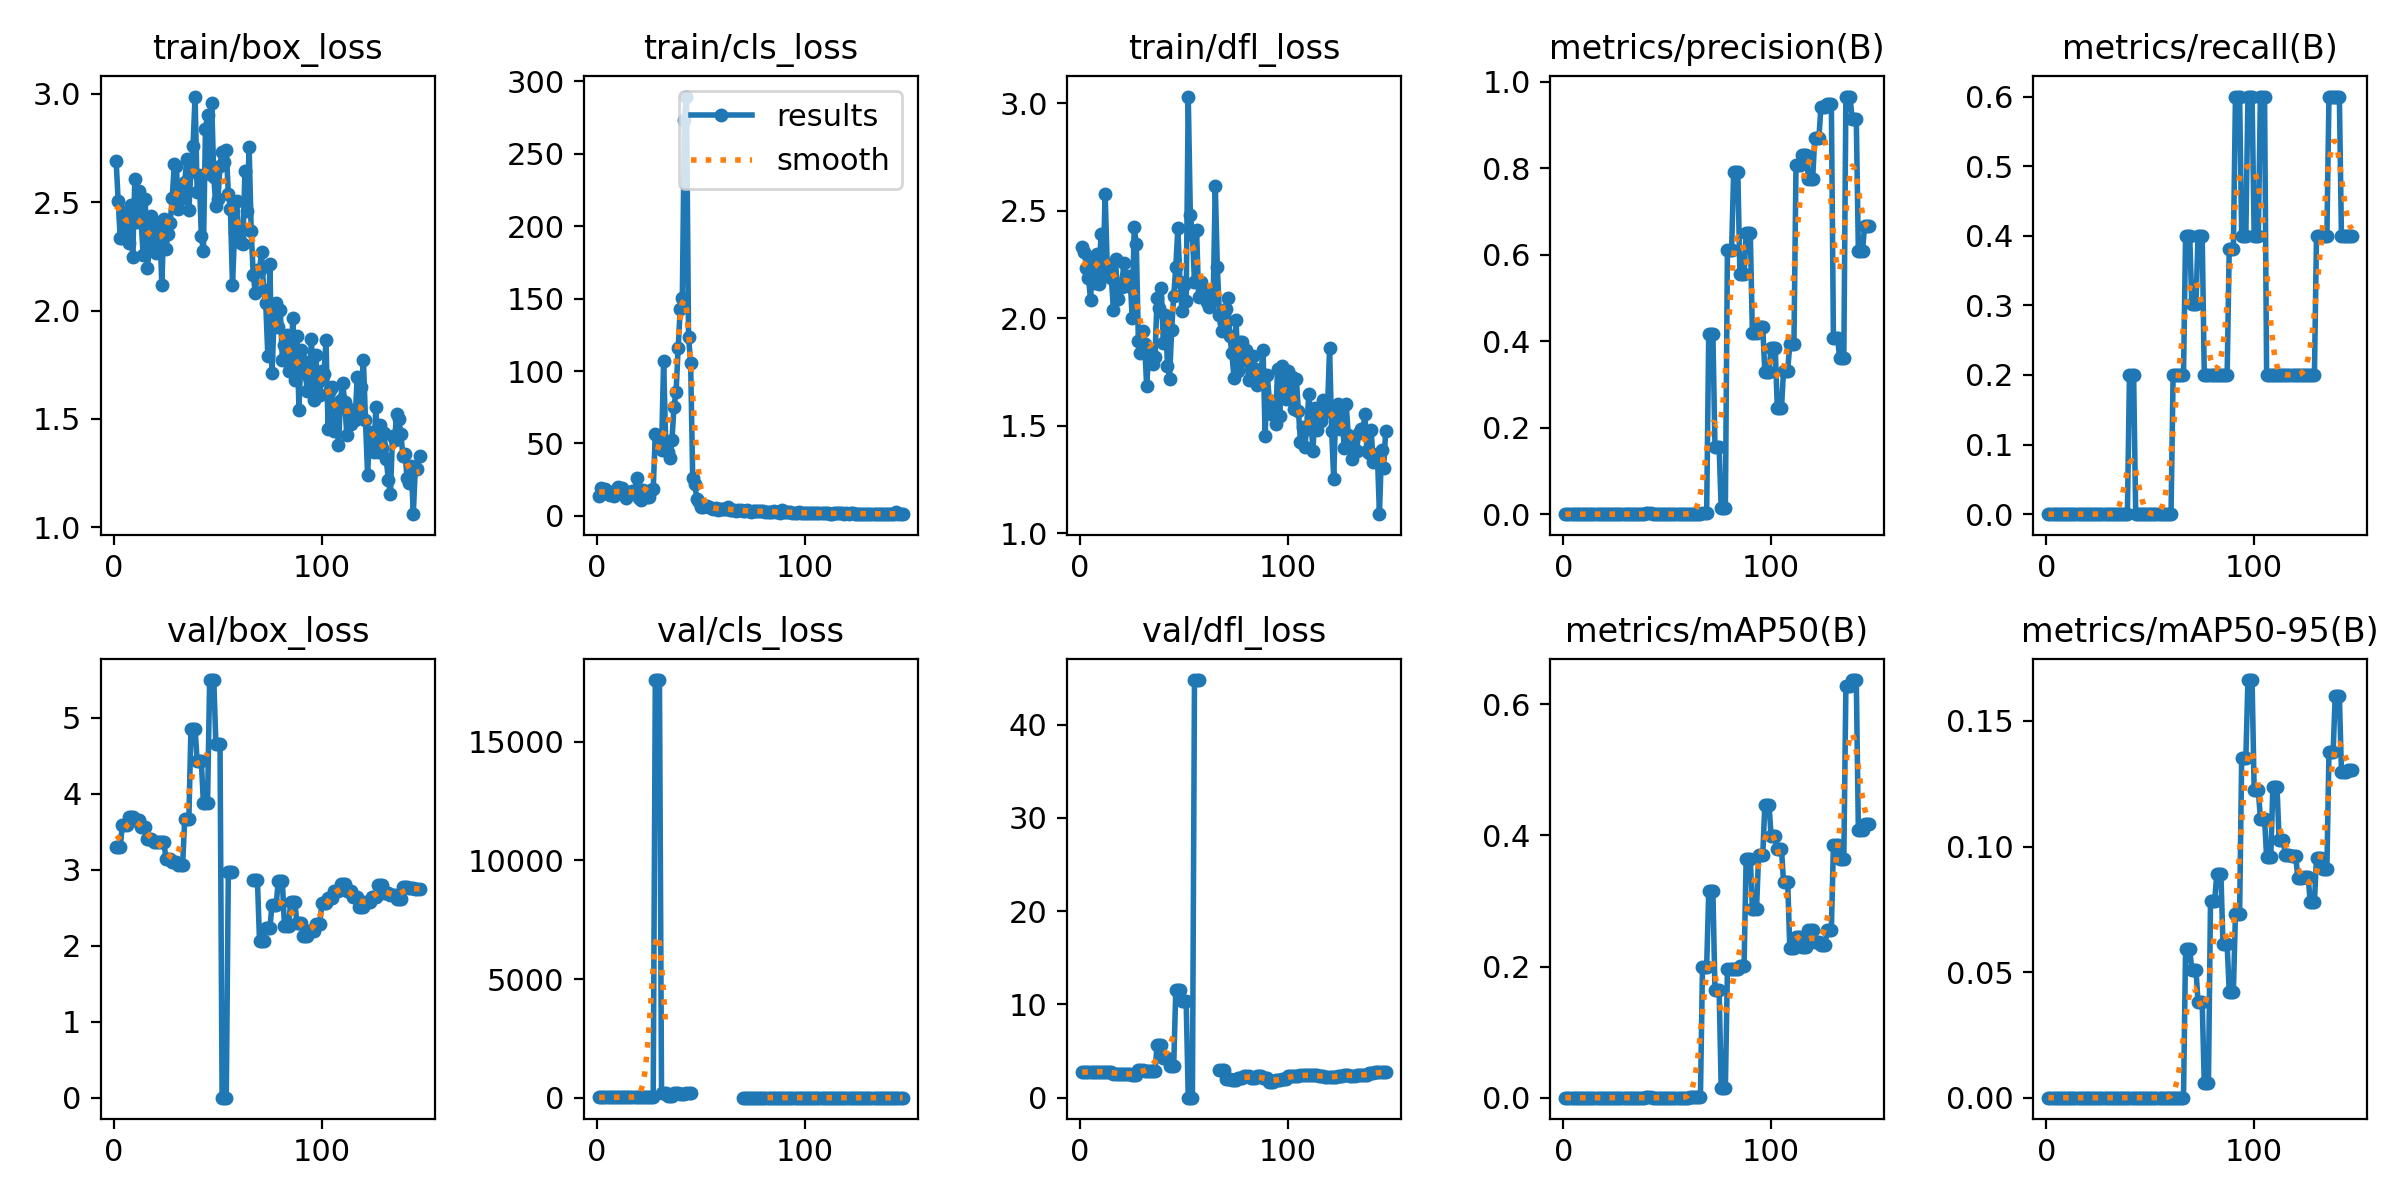

cancer_cbam


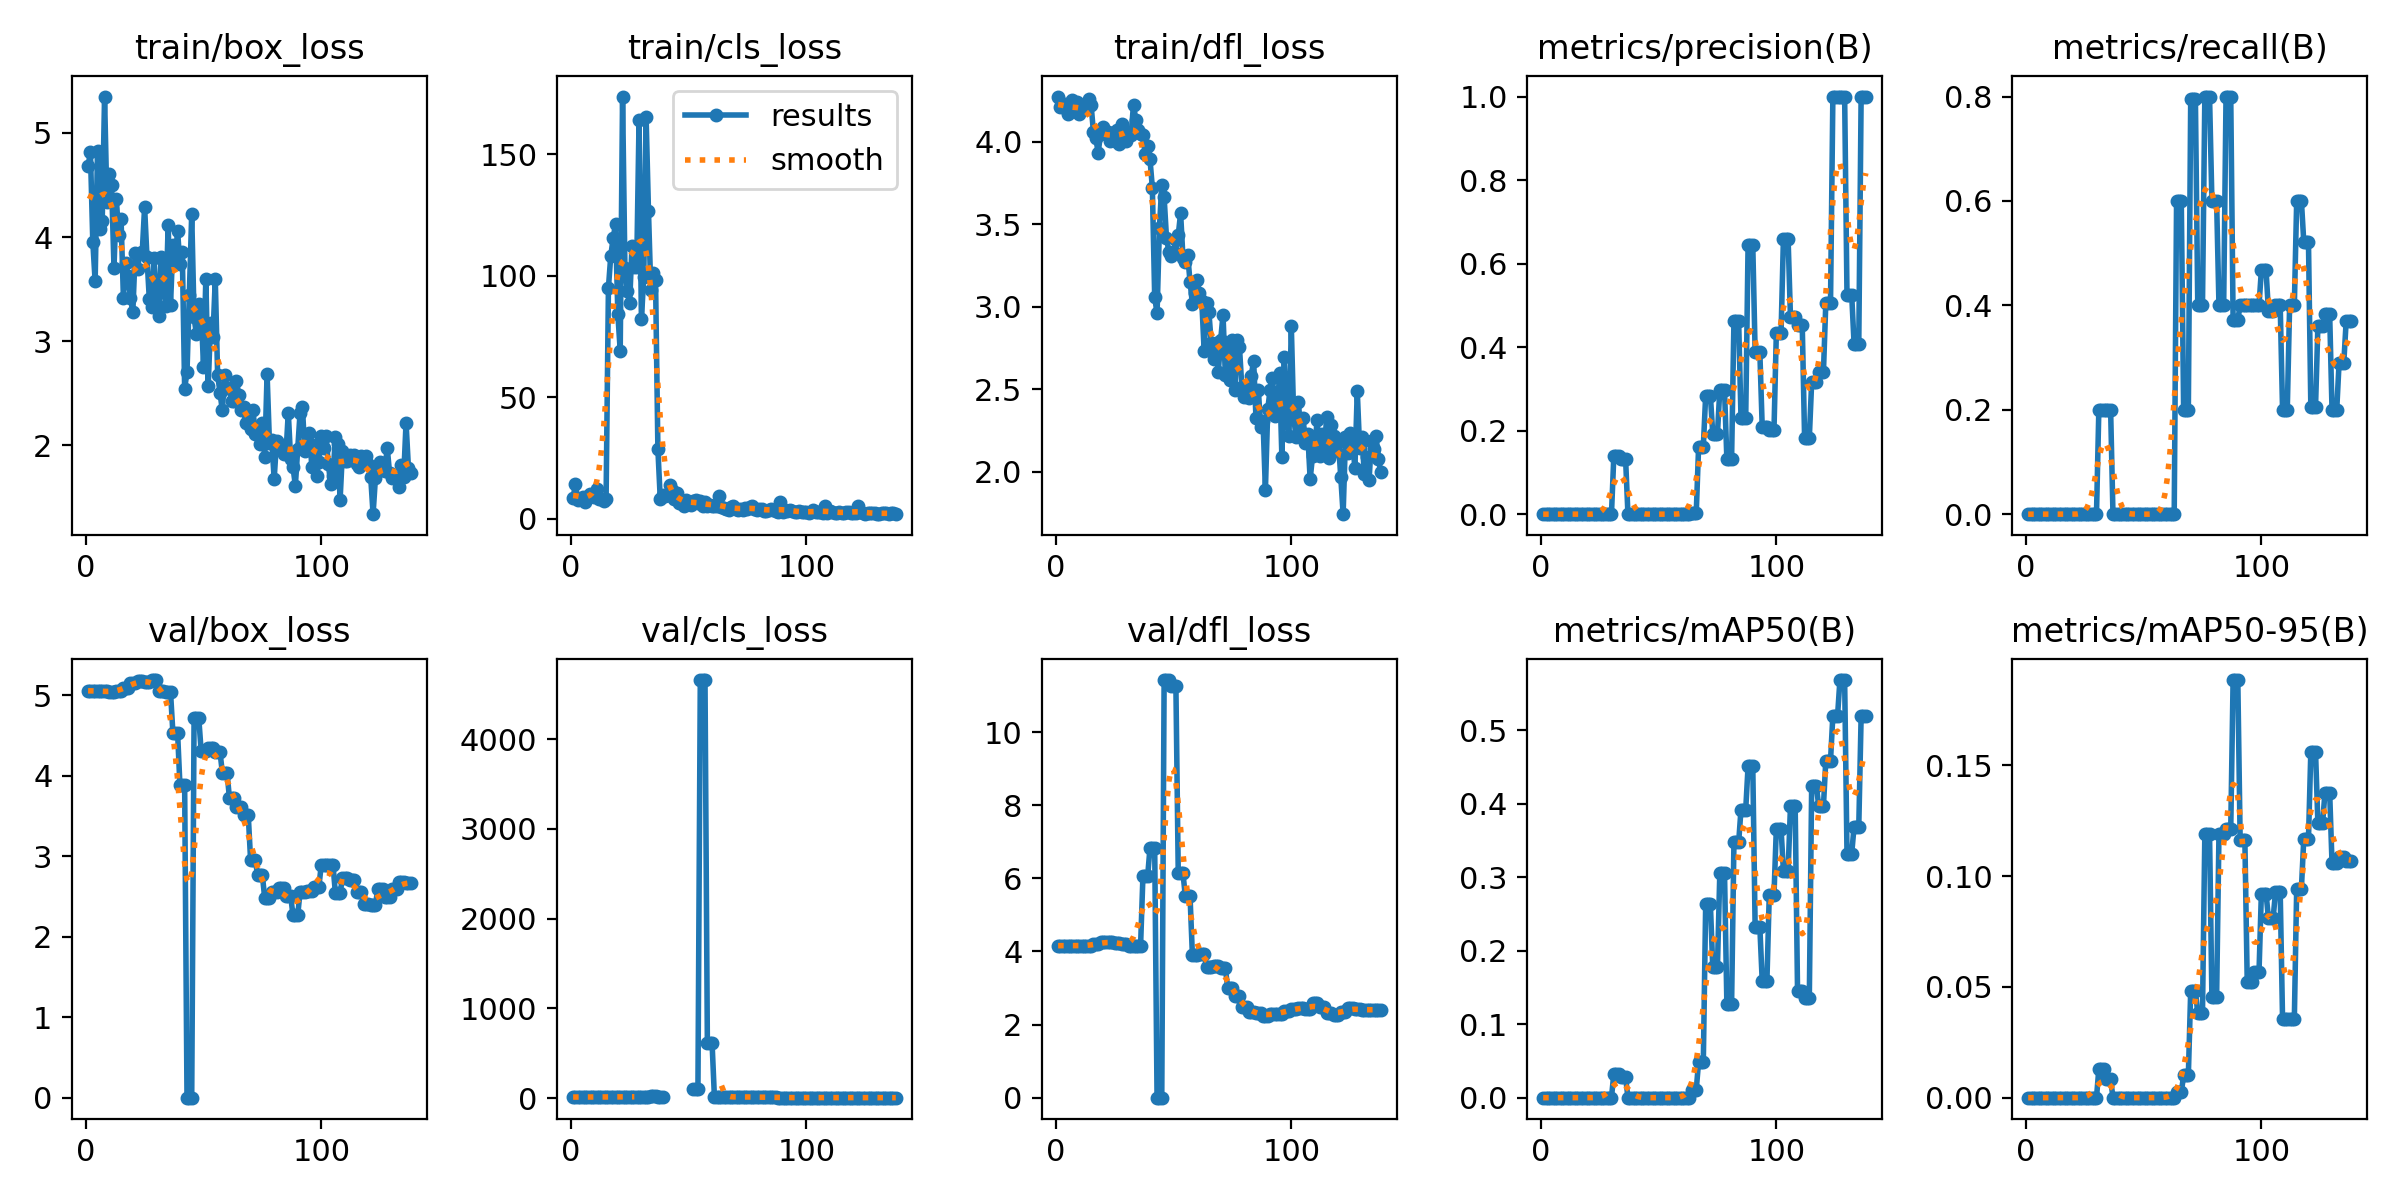

In [ ]:
from IPython.display import Image as IPyImage, display
import os
WORK = '/content/drive/MyDrive/cancer_images'
for run in ['cancer_base', 'cancer_cbam']:
    p = f'{WORK}/{run}/results.png'
    if os.path.exists(p): print(run); display(IPyImage(p))
    else: print('not found:', p)

In [ ]:
  import glob
  print(glob.glob('/content/drive/MyDrive/cancer_images/*'))

['/content/drive/MyDrive/cancer_images/cancer_yolov8', '/content/drive/MyDrive/cancer_images/cancer_base', '/content/drive/MyDrive/cancer_images/cancer_cbam']


## 5. Read the result

- This is your **ablation**: did adding attention improve YOLOv8 on cancer cells? Report the difference in mAP / count MAE (even a small, consistent gain is a valid finding).
- Tiny test set (3-4 images) -> treat as proof-of-concept; a multi-seed / more-data run would firm it up.
- If CBAM helps, note it narrows the gap to RetinaNet / Faster R-CNN from your 4-model comparison.